In [2]:
import pandas as pd

df = pd.read_csv('train_and_test2.csv')

In [3]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [4]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [5]:
colunas_zero = df.columns[df.columns.astype(str).str.contains('zero')]

In [6]:
colunas_zero

Index(['zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6',
       'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12',
       'zero.13', 'zero.14', 'zero.15', 'zero.16', 'zero.17', 'zero.18'],
      dtype='object')

In [7]:
df_limpo = df.drop(columns = colunas_zero)

In [8]:
df_limpo.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [9]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   2urvived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


In [10]:
df_limpo.dropna(inplace=True)

In [15]:
df_limpo.rename(columns = {"2urvived": "Survived"}, inplace = True)

In [16]:
X = df_limpo.drop(columns=['Survived'])
y = df_limpo['Survived']

In [17]:
from sklearn.model_selection import train_test_split
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [80]:
import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#Pipeline

pipeline = Pipeline(steps = [
    ('preprocessamento', StandardScaler()),
    ('LR', LogisticRegression(
        max_iter = 100000,
        random_state = 42
    ))


])

In [81]:
# grid_search values

parametros = { "LR__C": [0.01, 0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.8 ],
               "LR__solver": ["lbfgs", "liblinear", "saga"] }

grid = GridSearchCV(
estimator = pipeline,
param_grid = parametros,
scoring = "roc_auc",
cv = 5,
n_jobs = -1

)

grid.fit(X_treino, y_treino)

2026/07/26 21:13:11 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'adf17a80dccb49c485033dcf1d75fc82', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/07/26 21:13:11 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\anaconda\envs\titanic_predict\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Valu

🏃 View run industrious-crab-40 at: http://127.0.0.1:5000/#/experiments/1/runs/54dcdd92901a4393a9171a79c7b0ed7f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run intelligent-hen-231 at: http://127.0.0.1:5000/#/experiments/1/runs/28042066753446d39bc740442c14c1c7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run bedecked-squid-469 at: http://127.0.0.1:5000/#/experiments/1/runs/ae423bcc5a7140abbad5d6dac48162ec
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run stylish-auk-647 at: http://127.0.0.1:5000/#/experiments/1/runs/c3105e069bae46a681a3bb298bce7824
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run unruly-frog-706 at: http://127.0.0.1:5000/#/experiments/1/runs/1c1559efca63429e8ed60fdcb969c3b9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run resilient-rat-763 at: http://127.0.0.1:5000/#/experiments/1/runs/adf17a80dccb49c485033dcf1d75fc82
🧪 View experiment at: http://127.0.0.1:5000/#

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'LR__C': [0.01, 0.1, ...], 'LR__solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity 

In [84]:
modelo = grid.best_estimator_

In [85]:
print(grid.best_params_)
print(grid.best_score_)

{'LR__C': 0.3, 'LR__solver': 'lbfgs'}
0.8599295284925784


In [91]:
y_pred = modelo.predict(X_teste)
y_prob = modelo.predict_proba(X_teste)[:, 1]

metricas = {
            "accuracy_teste" : accuracy_score(y_teste, y_pred),
            "precision_teste" : precision_score(y_teste, y_pred,

            zero_division = 0),
            "f1_teste": f1_score(y_teste, y_pred, zero_division=0),

            "recall_teste" : recall_score(y_teste, y_pred),
            "roc_auc_teste" : roc_auc_score(y_teste, y_prob),
            "roc_auc_validacao" : grid.best_score_
            }



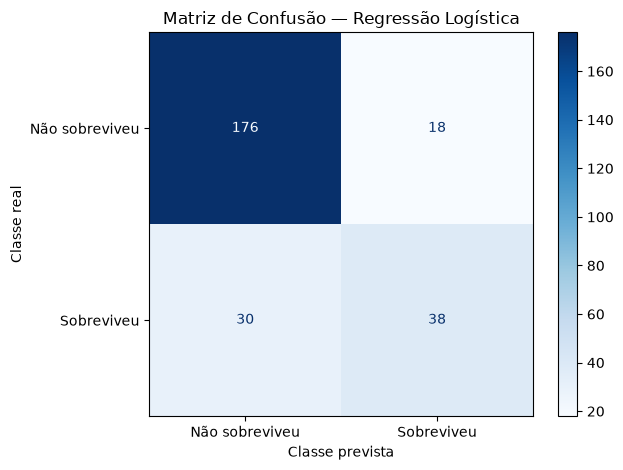

In [87]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)

# Melhor pipeline encontrado pelo GridSearch
modelo = grid.best_estimator_

# Previsões
y_pred = modelo.predict(X_teste)
y_prob = modelo.predict_proba(X_teste)[:, 1]

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    y_pred,
    display_labels=["Não sobreviveu", "Sobreviveu"],
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de Confusão — Regressão Logística")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.tight_layout()
plt.show()

In [88]:
print("Melhores parâmetros:")
print(grid.best_params_)

print("\nROC-AUC da validação cruzada:")
print(grid.best_score_)

print("\nROC-AUC no conjunto de teste:")
print(roc_auc_score(y_teste, y_prob))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_teste,
        y_pred,
        target_names=["Não sobreviveu", "Sobreviveu"],
        zero_division=0
    )
)

Melhores parâmetros:
{'LR__C': 0.3, 'LR__solver': 'lbfgs'}

ROC-AUC da validação cruzada:
0.8599295284925784

ROC-AUC no conjunto de teste:
0.8482413583990297

Relatório de classificação:
                precision    recall  f1-score   support

Não sobreviveu       0.85      0.91      0.88       194
    Sobreviveu       0.68      0.56      0.61        68

      accuracy                           0.82       262
     macro avg       0.77      0.73      0.75       262
  weighted avg       0.81      0.82      0.81       262



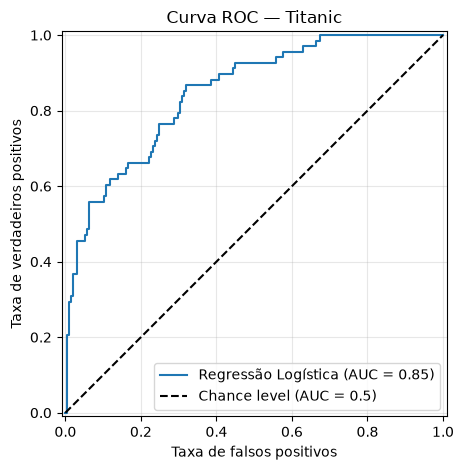

In [89]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

modelo = grid.best_estimator_

RocCurveDisplay.from_estimator(
    modelo,
    X_teste,
    y_teste,
    name="Regressão Logística",
    plot_chance_level=True
)

plt.title("Curva ROC — Titanic")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment(experiment_id="1")

regressao = modelo.named_steps["LR"]

mlflow.sklearn.autolog()
with mlflow.start_run(run_name="titanic-logistic-grid-search"):

    run_id = mlflow.active_run().info.run_id


    mlflow.log_params({
        "C": regressao.C,
        "solver": regressao.solver,
        "max_iter": regressao.max_iter,
        "random_state": regressao.random_state,
        
    })
    mlflow.log_metrics(metricas)

    mlflow.sklearn.log_model(
            sk_model=modelo,
            name="LR_grid_search"
        )

    print("Modelo salvo no MLflow")
    

Modelo salvo no MLflow
🏃 View run titanic-logistic-grid-search at: http://127.0.0.1:5000/#/experiments/1/runs/b0017fb45bf94e2e8e906fc193234275
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
